In [1]:
# importing the necessary libraries
import requests
import pandas as pd
import time
from tqdm import tqdm # Progress bar for better visibility
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix

#Importing tools for preprocessing before machine learning.
from sklearn.preprocessing import StandardScaler, MinMaxScaler # Converts big data into chunks that can be handled easily by the machine i.e standardizing the data
from sklearn.model_selection import train_test_split #Splits the data into 3;train,test and validation sets.

The cell below has been commented out since it was used in the initial data collection phase.

In [2]:
# # API Configuration
# API_URL =  "https://min-api.cryptocompare.com/data/v2/histohour"
# API_KEY = creds.API_KEY

# #  list of 30 cryptocurrencies and their most liquid exchanges
# coins_exchanges = {
#     "ADA": "Binance", "BCH": "Binance", "BCN": "HitBTC", 
#     "BTC": "Binance", "CND": "HitBTC", "CVC": "Binance",
#     "DASH": "Binance", "DATA": "Binance", "EOS": "Binance", 
#     "ETC": "Binance", "ETH": "Binance", "ETP": "HitBTC", 
#     "LTC": "Binance", "MANA": "Binance", "NEO": "Binance", 
#     "NXT": "HitBTC", "OMG": "Binance", "QTUM": "Binance", 
#     "RDD": "Bittrex", "SNT": "Binance", "TRX": "Binance", 
#     "VIB": "Binance", "WAVES": "Binance", "XDN": "HitBTC",
#     "XEM": "Binance", "XLM": "Binance", "XMR": "Binance", 
#     "XRP": "Binance", "XVG": "Bittrex", "ZEC": "Binance"
# }

# # Time Range
# start_date = "2024-01-01"  # Start date
# end_date = "2024-07-01"  # End date

# # Convert dates to UNIX timestamps
# start_ts = int(pd.Timestamp(start_date).timestamp())
# end_ts = int(pd.Timestamp(end_date).timestamp())

# # Initialize DataFrame to store all results
# all_data = []

# # Fetch data for each coin
# for coin, exchange in tqdm(coins_exchanges.items(), desc="Fetching Data"):
#     print(f"\nFetching data for {coin} from {exchange}...")

#     toTs = end_ts  # Start from the most recent timestamp
#     coin_data = []

#     while toTs > start_ts:
#         params = {
#             "fsym": coin,
#             "tsym": "USDT",  # All data in USDT
#             "e": exchange,  
#             "limit": 2000,  # Max per request
#             "toTs": toTs,
#             "api_key": API_KEY  # Add API key
#         }

#         response = requests.get(API_URL, params=params)
#         data = response.json()

#         if "Data" in data and "Data" in data["Data"]:
#             batch = data["Data"]["Data"]
#             if not batch:
#                 break  # Stop if no more data
            
#             coin_data.extend(batch)

#             # Get the earliest timestamp from the current batch to paginate
#             toTs = batch[0]["time"] - 1  # Move back in time
#         else:
#             print(f"Error fetching data for {coin}: {data}")
#             break

#         # Avoid rate limits
#         time.sleep(1)

#     # Convert to DataFrame
#     df = pd.DataFrame(coin_data)
#     if not df.empty:
#         df["time"] = pd.to_datetime(df["time"], unit="s")  # Convert timestamp
#         df["coin"] = coin
#         df["exchange"] = exchange
#         all_data.append(df)

# # Concatenate all coin data
# final_df = pd.concat(all_data, ignore_index=True)

# # Save to CSV
# final_df.to_csv("crypto_hourly_OHLCV.csv", index=False)

# print("\n✅ Data collection complete! Saved as crypto_hourly_OHLCV.csv")

In [3]:
# Load the dataset
df = pd.read_csv('crypto_hourly_OHLCV.CSV')

# Display the first few rows
df.head()

,time,close,high,low,open,volumefrom,volumeto,conversionType,conversionSymbol,coin,exchange
0,2024-04-08 16:00:00,0.6112,0.6115,0.6062,0.6074,4825802.1,2942962.56,force_direct,NaN,ADA,Binance
1,2024-04-08 17:00:00,0.6126,0.6138,0.6087,0.6112,3482941.5,2128869.38,force_direct,NaN,ADA,Binance
2,2024-04-08 18:00:00,0.6129,0.6144,0.6115,0.6126,3454875.1,2118343.33,force_direct,NaN,ADA,Binance
3,2024-04-08 19:00:00,0.6148,0.6151,0.6126,0.6129,3470461.3,2131618.81,force_direct,NaN,ADA,Binance
4,2024-04-08 20:00:00,0.6142,0.6152,0.6120,0.6148,2958147.2,1815447.80,force_direct,NaN,ADA,Binance


In [4]:
# Get basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180090 entries, 0 to 180089
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   time              180090 non-null  object 
 1   close             180090 non-null  float64
 2   high              180090 non-null  float64
 3   low               180090 non-null  float64
 4   open              180090 non-null  float64
 5   volumefrom        180090 non-null  float64
 6   volumeto          180090 non-null  float64
 7   conversionType    180090 non-null  object 
 8   conversionSymbol  0 non-null       float64
 9   coin              180090 non-null  object 
 10  exchange          180090 non-null  object 
dtypes: float64(7), object(4)
memory usage: 15.1+ MB


In [5]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
close,180090.0,1.915918e+03,9.952766e+03,0.000012,0.033110,0.45920,22.470,7.357735e+04
high,180090.0,1.922731e+03,9.988252e+03,0.000012,0.033320,0.46170,22.620,7.377700e+04
low,180090.0,1.908318e+03,9.913339e+03,0.000012,0.032933,0.45670,22.310,7.321514e+04
open,180090.0,1.915749e+03,9.952016e+03,0.000012,0.033110,0.45925,22.470,7.357735e+04
volumefrom,180090.0,1.827030e+06,6.836082e+06,0.000000,632.262500,28389.42500,735651.250,5.140477e+08
volumeto,180090.0,5.348566e+06,2.560899e+07,0.000000,36.735000,125143.84000,813077.705,1.433206e+09
conversionSymbol,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Check for missing values
print(df.isnull().sum())

time                     0
close                    0
high                     0
low                      0
open                     0
volumefrom               0
volumeto                 0
conversionType           0
conversionSymbol    180090
coin                     0
exchange                 0
dtype: int64


In [8]:
df = df.drop(columns = ["conversionType","exchange", "conversionSymbol"])

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'])

df.head()

,time,close,high,low,open,volumefrom,volumeto,coin
0,2024-04-08 16:00:00,0.6112,0.6115,0.6062,0.6074,4825802.1,2942962.56,ADA
1,2024-04-08 17:00:00,0.6126,0.6138,0.6087,0.6112,3482941.5,2128869.38,ADA
2,2024-04-08 18:00:00,0.6129,0.6144,0.6115,0.6126,3454875.1,2118343.33,ADA
3,2024-04-08 19:00:00,0.6148,0.6151,0.6126,0.6129,3470461.3,2131618.81,ADA
4,2024-04-08 20:00:00,0.6142,0.6152,0.6120,0.6148,2958147.2,1815447.80,ADA


## EXPLORATORY DATA ANALYSIS

### DATA PREPROCESSING 

#### FEATURE ENGINEERING

##### Additional Information Generated from the Dataset

- **Price Change:** Difference between close and open.

- **Hourly Return:** Percentage change in price from the previous hour. (we use the log returns)

- **Volatility:** std deviation of the returns. The Parkinson volatility estimator was used.

- **Volume Ratio:** Ratio of `volume_to` to `volume_from`.


In [28]:
# Price Change
df['price_change'] = df['close'] - df['open']

# Hourly Return
df['hourly_return'] = df.groupby('coin')['close'].transform(lambda x: np.log(x / x.shift(1)))

# Volatility using the Parkinson estimator
# volatility = sqrt(1 / (4 * ln(2))) * ln(high / low)
df['hourly_volatility'] = np.sqrt((1 / (4 * np.log(2))) * np.log(df['high'] / df['low'])**2)

# Volume Ratio
df['volume_ratio'] = df['volumeto'] / df['volumefrom']

# Drop the first row since pct_change() will result in NaN for the first row
df = df.dropna()

# view the changes
df.head()

,time,close,high,low,open,volumefrom,volumeto,coin,price_change,hourly_return,hourly_volatility,volume_ratio,future_return,median_return,target
22012,2023-10-24 23:00:00,33922.7300,34221.0000,33726.5100,34155.6400,2119.82,72015487.62,BTC,-232.9100,-0.006842,0.008741,33972.454086,-0.006883,-0.003932,0
52027,2023-10-24 23:00:00,0.5930,0.5980,0.5900,0.5970,383823.60,228174.38,EOS,-0.0040,-0.006723,0.008088,0.594477,-0.005888,-0.003932,0
178090,2023-10-24 23:00:00,27.5100,27.7200,27.4100,27.7000,786.93,21686.09,ZEC,-0.1900,-0.006883,0.006754,27.557839,-0.005335,-0.003932,0
166084,2023-10-24 23:00:00,0.5588,0.5628,0.5563,0.5621,10876480.00,6085302.35,XRP,-0.0033,-0.005888,0.006976,0.559492,0.004651,-0.003932,1
40021,2023-10-24 23:00:00,28.0400,28.2100,27.9000,28.1900,1543.81,43331.55,DASH,-0.1500,-0.005335,0.006636,28.067929,0.008381,-0.003932,1


##### Target Generation

In [36]:
# Sort by coin and time
df = df.sort_values(["coin", "time"])

# Compute the future return (2-hour ahead return) for each unique coin
df["future_return"] = df.groupby("coin")["hourly_return"].shift(-2)

# Computing the cross-sectional median return across all timestamps
df["median_return"] = df.groupby("time")["future_return"].transform("median")

# We then define the binary target variable which we will use to predict if the coin has outperfomed the crossectional median or not
df["target"] = (df["future_return"] >= df["median_return"]).astype(int)

# Dropping the missing values due to the shifting
df.dropna(inplace=True)

df.head()

,time,close,high,low,open,volumefrom,volumeto,coin,price_change,hourly_return,hourly_volatility,volume_ratio,future_return,median_return,target
4003,2023-10-24 23:00:00,0.2792,0.2808,0.2783,0.2803,1676359.3,468668.56,ADA,-0.0011,-0.003932,0.005371,0.279575,0.002125,0.001738,1
4004,2023-10-25 00:00:00,0.2821,0.2823,0.2784,0.2792,2987225.3,836054.59,ADA,0.0029,0.010333,0.008355,0.279877,-0.004254,-0.006841,1
4005,2023-10-25 01:00:00,0.2827,0.2850,0.2819,0.2821,4289901.9,1216736.71,ADA,0.0006,0.002125,0.006568,0.283628,-0.004629,-0.004359,0
4006,2023-10-25 02:00:00,0.2815,0.2831,0.2799,0.2827,3617633.6,1017616.83,ADA,-0.0012,-0.004254,0.006827,0.281294,0.007821,0.007103,1
4007,2023-10-25 03:00:00,0.2802,0.2816,0.2794,0.2815,1868170.5,524204.56,ADA,-0.0013,-0.004629,0.004710,0.280598,-0.007107,-0.007005,0


In [47]:
# Finally we define the features column our target variable and the y variable
feature_columns = ['close', 'high', 'low', 'open', 'coin', 'price_change', 'hourly_return', 
                   'hourly_volatility', 'volume_ratio', 'future_return']
X = df[feature_columns]  
y = df["target"]

In [48]:
# encoding the categorical variables
X = pd.get_dummies(X, columns=["coin"])
X.head()

,close,high,low,open,price_change,hourly_return,hourly_volatility,volume_ratio,future_return,coin_ADA,...,coin_TRX,coin_VIB,coin_WAVES,coin_XDN,coin_XEM,coin_XLM,coin_XMR,coin_XRP,coin_XVG,coin_ZEC
4003,0.2792,0.2808,0.2783,0.2803,-0.0011,-0.003932,0.005371,0.279575,0.002125,True,...,False,False,False,False,False,False,False,False,False,False
4004,0.2821,0.2823,0.2784,0.2792,0.0029,0.010333,0.008355,0.279877,-0.004254,True,...,False,False,False,False,False,False,False,False,False,False
4005,0.2827,0.2850,0.2819,0.2821,0.0006,0.002125,0.006568,0.283628,-0.004629,True,...,False,False,False,False,False,False,False,False,False,False
4006,0.2815,0.2831,0.2799,0.2827,-0.0012,-0.004254,0.006827,0.281294,0.007821,True,...,False,False,False,False,False,False,False,False,False,False
4007,0.2802,0.2816,0.2794,0.2815,-0.0013,-0.004629,0.004710,0.280598,-0.007107,True,...,False,False,False,False,False,False,False,False,False,False


##### SPLITTING THE DATASET INTO TRAINING AND TESTING 

In [49]:
# Time-based train-test split (80% train, 20% test)-- this is safe to retain the chronological order  of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) 

In [50]:
# Standardizing the features to easily work with each of them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### DEFINING AND TRAINING THE MODEL

In [51]:
# Train the Logistic Regression model
log_reg = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=100)

In [52]:
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

In [53]:
# Make predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred

array([0, 1, 0, ..., 1, 1, 0])

In [64]:
# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:, 1])

print("\nModel Accuracy:", accuracy)
print("ROC AUC Score:", roc_auc)
print("\n===========================================================================\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


Model Accuracy: 0.677290111090876
ROC AUC Score: 0.7317474269679909


Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.64      0.66     13329
           1       0.68      0.71      0.69     14126

    accuracy                           0.68     27455
   macro avg       0.68      0.68      0.68     27455
weighted avg       0.68      0.68      0.68     27455



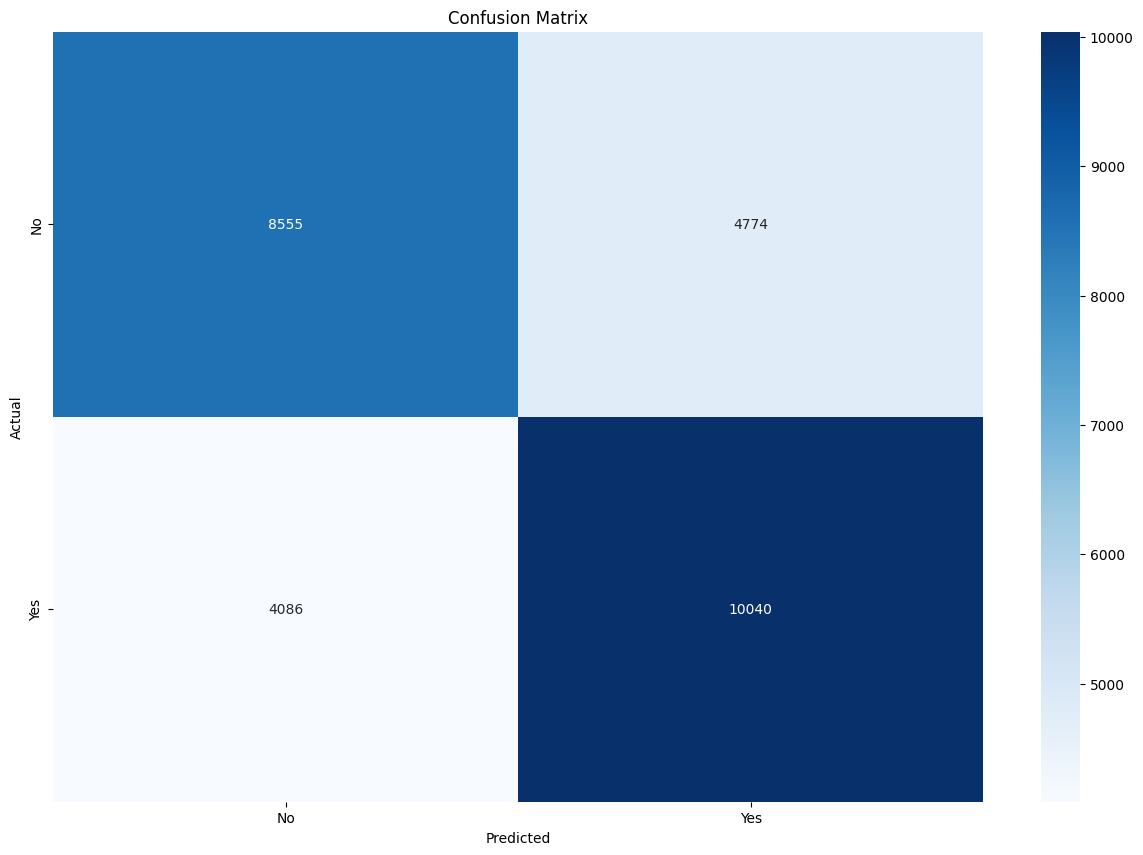

In [58]:
# Plotting the  Confusion Matrix
plt.figure(figsize=(15, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


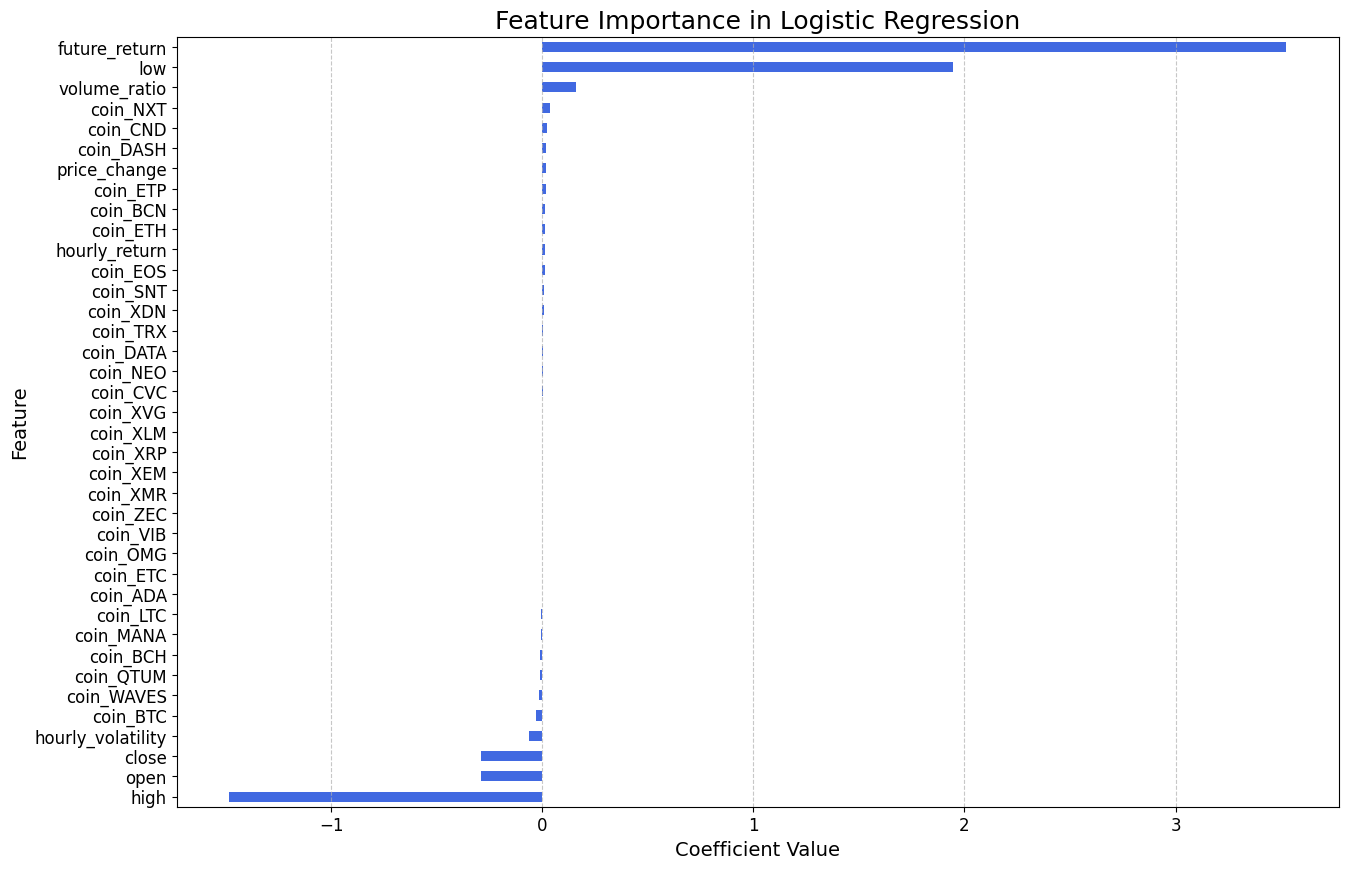

In [65]:
# Plot Feature Importance (Logistic Regression Coefficients)
plt.figure(figsize=(15, 10))  # Adjusted for full-page effect

# Plot feature importance
feature_importance = pd.Series(log_reg.coef_[0], index=X.columns)
feature_importance.sort_values().plot(kind="barh", color="royalblue")

# Labels and title
plt.xlabel("Coefficient Value", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.title("Feature Importance in Logistic Regression", fontsize=18)

# Improve layout
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()